In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from scipy.integrate import solve_ivp
from sklearn.model_selection import train_test_split

import torch
from torch import nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from torchdiffeq import odeint

In [2]:
device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "mps" if torch.backends.mps.is_available()
    else "cpu"
)

print("Using device:", device)

Using device: cpu


## Part 1. Analysing the dynamics of the Lorenz system

##### 1. Lorenz system function

We create a function that represents differential equations in the Lorenz system. Eve though we don't use time inside the function it should be there for the compatibility purposes.

In [3]:
def lorenz_ode (t, X):
  sig=10
  rho=28
  beta= 8/3
  x,y,z = X.T
  f = np.array([sig*(y-x), x*(rho-z)-y, x*y-beta*z])
  return f

##### 2. Initial conditions and solution of the system

We numerically integrate the differential equations using `scipy.integrate.solve_ivp` for two different sets of initial conditions. The difference between initial conditions is just $10^{-9}$ in the $z$ direction.

In [6]:
t = np.linspace(0, 40, 10000)
y_0 = np.array([5,5,5]).T
sol1= solve_ivp(lorenz_ode, (t[0], t[-1]), y_0, rtol=1e-10, atol=1e-12, t_eval=t)

In [7]:
eps = 1e-9
y_01 = np.array([5,5,5+eps]).T
sol2 = solve_ivp(lorenz_ode, (t[0], t[-1]), y_01, rtol=1e-10, atol=1e-12, t_eval=t)

##### 3. Plot the trajectories

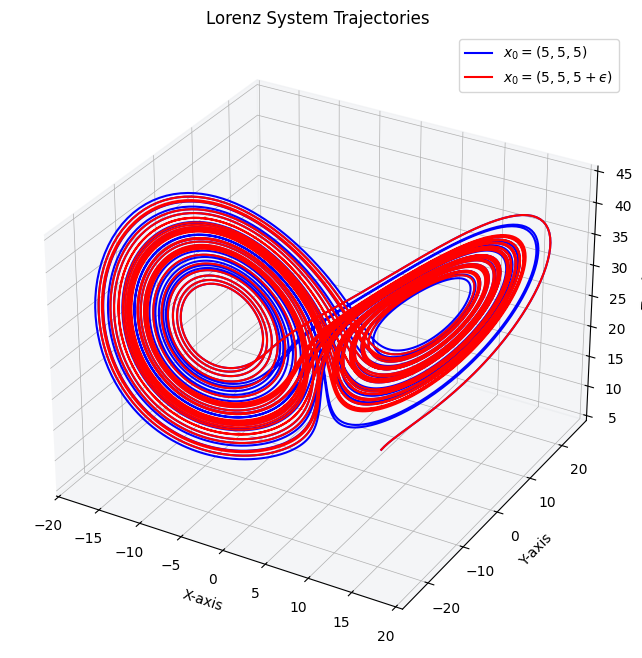

In [8]:
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection = '3d')
ax.plot(sol1.y[0], sol1.y[1], sol1.y[2], label=f'$x_0 = (5,5,5)$', color ='b')
ax.plot(sol2.y[0], sol2.y[1], sol2.y[2], label = f'$x_0 = (5,5,5+ϵ)$', color = 'r')
ax.legend()
ax.set_xlabel('X-axis')
ax.set_ylabel('Y-axis')
ax.set_zlabel('Z-axis')
ax.set_title('Lorenz System Trajectories')
plt.show()

We see that even though the general shape is the same, the trajectories are not (othervise we would see mostly one color). Now we invetigate the distance between trajectories (positions of points in two trajectories at the same time).

In [9]:
dist = np.sqrt((sol1.y[0]-sol2.y[0])**2 + (sol1.y[1]-sol2.y[1])**2 + (sol1.y[2]-sol2.y[2])**2)

Text(0.5, 1.0, 'Distance Between Solutions')

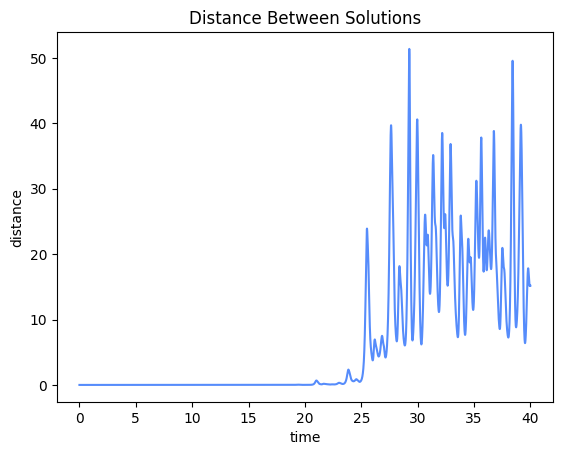

In [11]:
plt.plot(t,dist)
plt.xlabel('time')
plt.ylabel('distance')
plt.title('Distance Between Solutions')

##### 5. Lyapunov time calculation

We take 100 uniformly distributed points as a first set of initial conditions and add $10^{-9}$ to a random directon, creating this way the second set of initial conditions. Then we solve the Lorenz system for the both sets.

In [ ]:
# unshifted initial conditions
X_1 = np.linspace((-15,-15,0), (15,15,30), 100)

# initiall shift towards different directions
i = np.random.randint(0, 3, size=X_1.shape[0])
eps_1 = 1e-9

# shift in the initial conditions
X_2 = np.copy(X_1)
X_2[np.arange(X_2.shape[0]), i] += eps_1

In [16]:
# trajectories for unshifted conditions
solutions = []
for i in tqdm(range(X_1.shape[0])):
  sol3 = solve_ivp(lorenz_ode, (t[0], t[-1]), X_1[i], rtol=1e-10, atol=1e-12, t_eval=t)
  solutions.append(sol3)


100%|██████████| 100/100 [02:32<00:00,  1.52s/it]


In [15]:
# trajectories for shifted conditions
solutions2 = []
for i in tqdm(range(X_2.shape[0])):
  sol4 = solve_ivp(lorenz_ode, (t[0], t[-1]), X_2[i], rtol=1e-10, atol=1e-12, t_eval=t)
  solutions2.append(sol4)

100%|██████████| 100/100 [02:30<00:00,  1.51s/it]


We plot one of trajectories (both for unshifted initial conditions and the corresponding shifted ones)

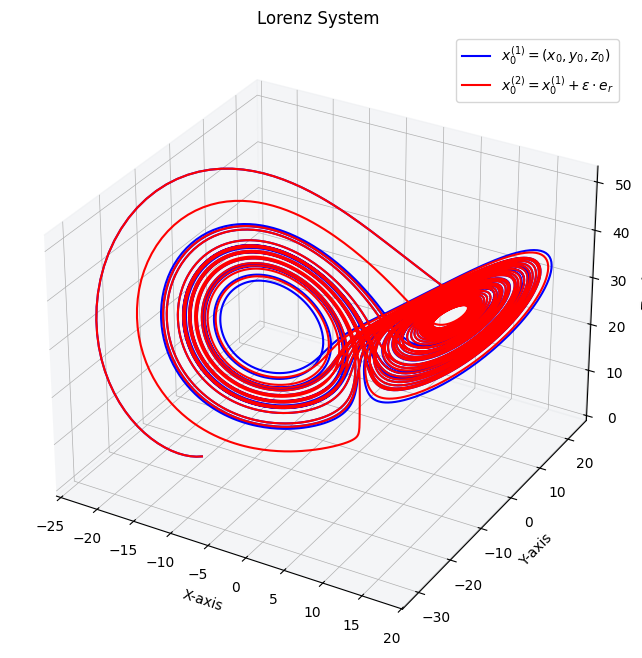

In [17]:
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection = '3d')
ax.plot(solutions[0].y[0], solutions[0].y[1], solutions[0].y[2], label=r'$x_0^{(1)} = (x_0,y_0,z_0)$', color ='b')
ax.plot(solutions2[0].y[0], solutions2[0].y[1], solutions2[0].y[2],label=r'$x_0^{(2)} = x_0^{(1)} + \epsilon \cdot e_r$', color ='r')
ax.legend()
ax.set_xlabel('X-axis')
ax.set_ylabel('Y-axis')
ax.set_zlabel('Z-axis')
ax.set_title('Lorenz System')
plt.show()

Now we calculate the average separation for each snapshot (point in time)

In [18]:
traj1 = np.stack([sol.y for sol in solutions], axis=0)
traj2 = np.stack([sol.y for sol in solutions2], axis=0)
traj1 = traj1.transpose(0,2,1)
traj2 = traj2.transpose(0,2,1)

diff = traj1 - traj2

dist2 = np.linalg.norm(diff, axis=2)

means = np.mean(dist2, axis = 0)

Text(0.5, 1.0, 'Distance Between Solutions')

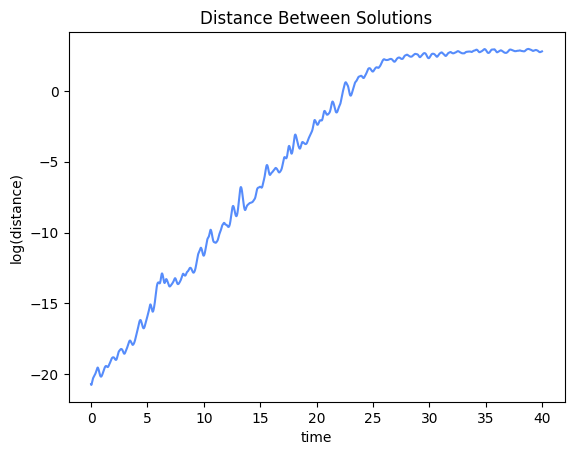

In [19]:
plt.plot(t,np.log(means))
plt.xlabel('time')
plt.ylabel('log(distance)')
plt.title('Distance Between Solutions')

We see that separation saturates at $t\approx25$. To estimate the Lyapunov time fe fit the part before the saturation with a linear dependency.

In [20]:
val = np.argmin(np.abs(t-25))
a, b =np.polyfit(t[:val], np.log(means[:val]), deg=1)
print(val)

6249


In [22]:
print(f"Lyapunov time: {1/a:.2f}")

Lyapunov time: 1.11


Text(0.5, 1.0, 'Distance Between Solutions')

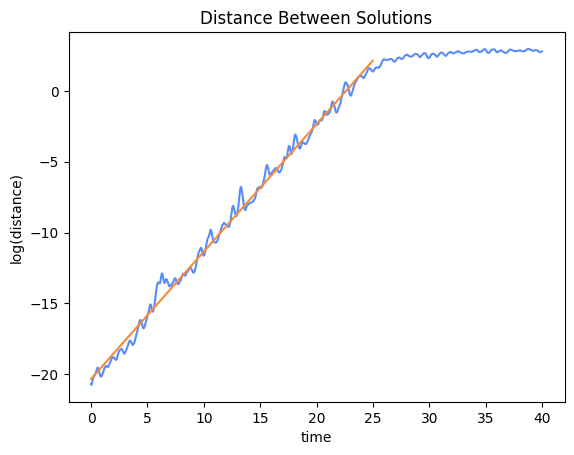

In [23]:
y = a*t[:val] +b

plt.plot(t,np.log(means))
plt.plot(t[:val], y )
plt.xlabel('time')
plt.ylabel('log(distance)')
plt.title('Distance Between Solutions')

## Part 2. Machine learning the dynamics of the Lorenz system

##### 1. Training data

Now we take again 100 points (initial conditions) within the same limits, but this time we choose them randomly. Then we solve Lorenz system for them.

In [4]:
X_ini = np.random.rand(100, 3)*30 - np.array([15,15,0])
t1 = np.linspace(0, 4, 400)

solutions3 = []
for i in range(X_ini.shape[0]):
  sol3 = solve_ivp(lorenz_ode, (t1[0], t1[-1]), X_ini[i], rtol=1e-10, atol=1e-12, t_eval=t1)
  solutions3.append(sol3.y)
solutions3 = np.array(solutions3)

We plot all of the trajectories together

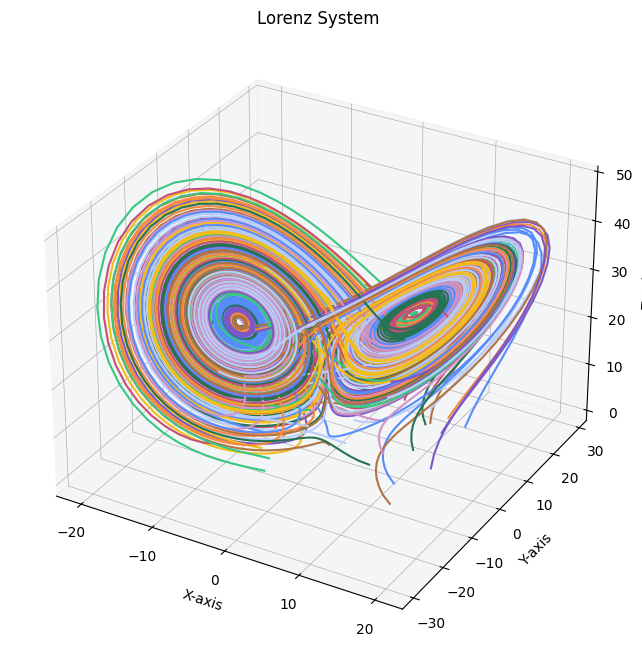

In [5]:
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection = '3d')
for i in range(len(solutions3)):
    ax.plot(solutions3[i, 0], solutions3[i, 1], solutions3[i, 2])
ax.set_xlabel('X-axis')
ax.set_ylabel('Y-axis')
ax.set_zlabel('Z-axis')
ax.set_title('Lorenz System')
plt.show()

##### 2. Data normalization

We split the trajectories into the trainig (80%) and the test (20%) datasets. Then we transpose them so the first index is the id of the rajectory, the second one is the timestamp and the third is coordinate. We normalize the training dataset and keep the normalization range. Then we normalize the test dataset _using the same range_. The input data for the NN is the coordinates on a step $i$, the output is the coordinates on a step $i+1$. We do not distinguish between different trajectories as long as we remember the next step coordinates for each point of each trajectory.

We put all this operations into one function, because we are going to reuse it for the data with noise.

In [6]:
def normalize(a, exax=0, minvals=0, maxvals=1, mins=None, maxs=None):
    """
    Normalizes an input array along a specified axis using provided minimum and maximum
    values or calculates them dynamically if not provided.

    This function rescales the values of the input array 'a' into a specified range
    (defined by 'minvals' and 'maxvals') for the given axis. If 'mins' and 'maxs'
    are not supplied, the element-wise minimum and maximum of the array 'a'
    are used in normalization respectively.

    :param a: Input array to be normalized.
    :param exax: Axis along which to normalize. The default value is 0.
    :param minvals: Lower bound of the normalization range. Defaults to 0.
    :param maxvals: Upper bound of the normalization range. Defaults to 1.
    :param mins: Pre-computed minimum values for normalization. If None,
                 the function computes the minimum dynamically.
    :param maxs: Pre-computed maximum values for normalization. If None,
                 the function computes the maximum dynamically.
    :return: Normalized array with values rescaled into the specified range.
    :rtype: Same as type of input array.
    """
    axis = set(np.arange(len(a.shape)).tolist())
    axis.remove(exax)
    if mins is None:
        mins = np.min(a, axis=tuple(axis))
    if maxs is None:
        maxs = np.max(a, axis=tuple(axis))

    return (maxvals-minvals)*(a - mins) / (maxs - mins) + minvals, mins, maxs

In [7]:
def denormalize(normalized_a, physical_mins, physical_maxs, target_minvals, target_maxvals):
    """Reverses the normalization process."""
    return (normalized_a - target_minvals) * (physical_maxs - physical_mins) / (target_maxvals - target_minvals) + physical_mins

In [8]:
def make_loader(X, y, batch_size=256, shuffle=True):
    print(X.shape)
    X_tensor = torch.as_tensor(X, dtype=torch.float32)
    print(X_tensor.shape)
    y_tensor = torch.as_tensor(y, dtype=torch.float32)
    return DataLoader(TensorDataset(X_tensor, y_tensor), batch_size=batch_size, shuffle=shuffle)

In [39]:
def setup_training_dataset(trajectories, noise_level=0.0):
    noise = noise_level*np.random.randn(*np.array(trajectories).shape)
    print(noise)
    traj_train, traj_test = train_test_split(trajectories + noise, test_size=0.2, random_state=1)

    '''Before the transponse:
    0 - "id" (number of trajectory)
    1 - coordinate (x, y, z)
    2 - time
    '''
    traj_train = traj_train.transpose(0,2,1)
    traj_test = traj_test.transpose(0,2,1)

    traj_train, mins, maxs = normalize(traj_train, 2, minvals=np.array([-1,-1,0]), maxvals=np.array([1,1,2]))
    traj_test, _, _ = normalize(traj_test, 2, mins=mins, maxs=maxs, minvals=np.array([-1,-1,0]), maxvals=np.array([1,1,2]))

    X_train, y_train = traj_train[:, :-1], traj_train[:, 1:]
    X_test, y_test = traj_test[:, :-1], traj_test[:, 1:]

    X_train, y_train = X_train.reshape(-1, 3), y_train.reshape(-1, 3)
    X_test, y_test = X_test.reshape(-1, 3), y_test.reshape(-1, 3)

    train_loader = make_loader(X_train, y_train, batch_size=256, shuffle=True)
    val_loader = make_loader(X_test, y_test, batch_size=256, shuffle=False)

    return train_loader, val_loader, traj_train, traj_test, mins, maxs

In [10]:
train_loader, val_loader, traj_train, traj_test, mins, maxs = setup_training_dataset(solutions3)

(31920, 3)
torch.Size([31920, 3])
(7980, 3)
torch.Size([7980, 3])


##### 3. Multilayer perceptron

We create a two-layer FNN with 100 neurons in each layer.

In [11]:
class History:
    def __init__(self):
        self.history = {"loss": [], "val_loss": []}


def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


class FeedForwardNN(nn.Module):
    """One-step predictor: maps x(t_k) -> x(t_{k+1})."""
    def __init__(self, dim=3, hidden=20):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(dim, hidden),
            nn.Tanh(),
            nn.Linear(hidden, hidden),
            nn.ReLU(),
            nn.Linear(hidden, dim),   # no activation after the output
        )

    def forward(self, x):
        return self.net(x)


model = FeedForwardNN(dim=3, hidden=100).to(device)
print(model)
print(f"Trainable params: {count_parameters(model):,}")

loss_fn = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

FeedForwardNN(
  (net): Sequential(
    (0): Linear(in_features=3, out_features=100, bias=True)
    (1): Tanh()
    (2): Linear(in_features=100, out_features=100, bias=True)
    (3): ReLU()
    (4): Linear(in_features=100, out_features=3, bias=True)
  )
)
Trainable params: 10,803


We train our model for 200 epochs with adam minimizer.

In [13]:
def train_model(model, train_loader, optimizer, loss_fn, epochs, val_loader=None):
    hist = History()
    for epoch in range(epochs):
        model.train()
        train_loss, train_count = 0.0, 0
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad(set_to_none=True)
            loss = loss_fn(model(xb), yb)
            loss.backward()
            optimizer.step()
            train_loss += loss.item() * xb.shape[0]
            train_count += xb.shape[0]
        train_loss /= train_count
        hist.history["loss"].append(train_loss)
        message = f"Epoch {epoch + 1}/{epochs} - loss: {train_loss:.6g}"

        if val_loader is not None:
            model.eval()
            val_loss, val_count = 0.0, 0
            with torch.no_grad():
                for xb, yb in val_loader:
                    xb, yb = xb.to(device), yb.to(device)
                    val_loss += loss_fn(model(xb), yb).item() * xb.shape[0]
                    val_count += xb.shape[0]
            val_loss /= val_count
            hist.history["val_loss"].append(val_loss)
            message += f" - val_loss: {val_loss:.6g}"

        if epoch == 0 or (epoch + 1) % 10 == 0:
            print(message)
    return hist

In [14]:
hist = train_model(model, train_loader, optimizer, loss_fn, epochs=200, val_loader=val_loader)

Epoch 1/200 - loss: 0.024745 - val_loss: 0.000304783
Epoch 10/200 - loss: 1.77121e-05 - val_loss: 2.03367e-05
Epoch 20/200 - loss: 1.21111e-05 - val_loss: 1.98874e-05
Epoch 30/200 - loss: 1.03348e-05 - val_loss: 6.41912e-06
Epoch 40/200 - loss: 9.04827e-06 - val_loss: 5.64244e-06
Epoch 50/200 - loss: 1.08849e-05 - val_loss: 5.17219e-06
Epoch 60/200 - loss: 7.83604e-06 - val_loss: 1.15874e-05
Epoch 70/200 - loss: 8.89929e-06 - val_loss: 1.28397e-05
Epoch 80/200 - loss: 9.77863e-06 - val_loss: 1.57064e-05
Epoch 90/200 - loss: 8.24897e-06 - val_loss: 5.39151e-06
Epoch 100/200 - loss: 4.6846e-06 - val_loss: 4.87361e-06
Epoch 110/200 - loss: 6.72463e-06 - val_loss: 8.85726e-06
Epoch 120/200 - loss: 8.94576e-06 - val_loss: 4.28742e-06
Epoch 130/200 - loss: 8.53537e-06 - val_loss: 5.67152e-06
Epoch 140/200 - loss: 5.81846e-06 - val_loss: 3.18539e-06
Epoch 150/200 - loss: 6.93543e-06 - val_loss: 8.79246e-06
Epoch 160/200 - loss: 6.93484e-06 - val_loss: 6.77421e-06
Epoch 170/200 - loss: 6.27521

Training curve

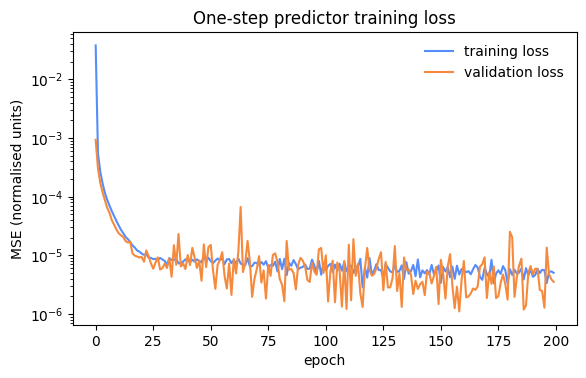

In [15]:
fig, ax = plt.subplots(figsize=(6.5, 3.8))
ax.semilogy(hist.history["loss"], label="training loss")
ax.semilogy(hist.history["val_loss"], label="validation loss")
ax.legend(frameon=False)
ax.set_xlabel("epoch")
ax.set_ylabel("MSE (normalised units)")
ax.set_title("One-step predictor training loss")
plt.show()

##### 4. Investigating MLP results

We go from point to the next point using trained NN to predict our next position

In [15]:
def rollout(model, x0_normalized, n_steps):
    """Iterate the one-step predictor n_steps times, starting from x0_normalized (already normalized units).
    Returns the sequence of predicted states in normalized units.
    """
    model.eval()
    # Initialize array to store predicted states in normalized units
    xs_predicted_normalized = np.zeros((n_steps + 1, 3))

    xs_predicted_normalized[0] = x0_normalized # Store the initial normalized point
    current_normalized_x = np.array([x0_normalized]) # Wrap for batch dimension (1,3)

    with torch.no_grad():
        for k in range(n_steps):
            # Feed normalized x to the model
            # model expects (batch_size, dim) -> (1, 3) in this case
            # model output xn_next_normalized will be (1, 3)
            xn_next_normalized_tensor = model(torch.as_tensor(current_normalized_x, dtype=torch.float32, device=device))
            xn_next_normalized = xn_next_normalized_tensor.cpu().numpy()

            # Store the predicted normalized state (remove the batch dimension)
            xs_predicted_normalized[k + 1] = xn_next_normalized[0]

            # For the next step, use this predicted normalized output
            current_normalized_x = xn_next_normalized

    return xs_predicted_normalized

/tmp/ipykernel_49718/379530212.py:29: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[0, 0].legend(frameon=False)


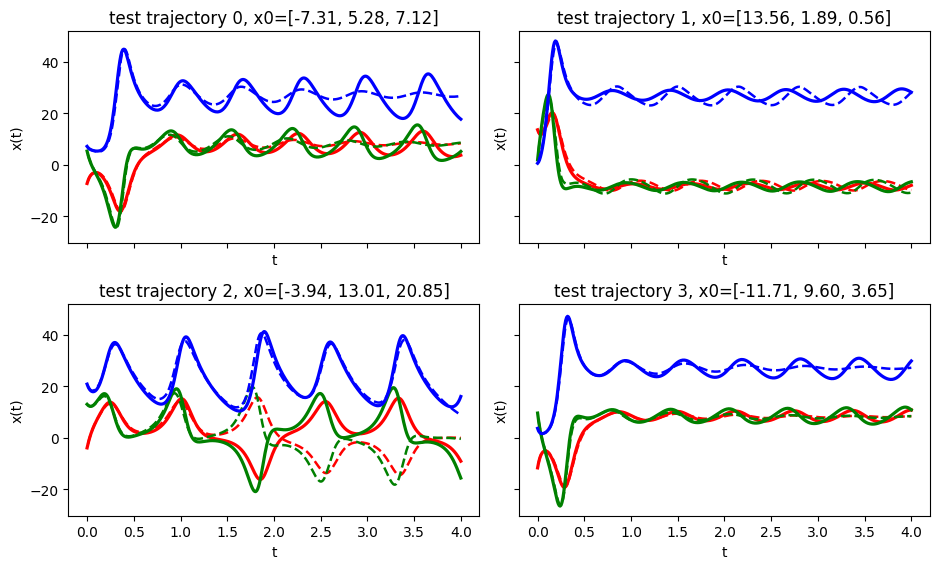

In [16]:

# Define the global min/max for the physical data and the target ranges used in normalize/denormalize
# 'mins' and 'maxs' are available globally from the training data normalization.
global_physical_mins = mins
global_physical_maxs = maxs
global_target_minvals = np.array([-1,-1,0])
global_target_maxvals = np.array([1,1,2])

# evaluate on the held-out test trajectories: start the rollout from each test trajectory's
# initial point and compare against the stored true trajectory (no re-integration needed)
n_show = min(4, traj_test.shape[0])
fig, axes = plt.subplots(2, 2, figsize=(9.5, 5.8), sharex=True, sharey=True)
for ax, j in zip(axes.ravel(), range(n_show)):
    true_i_normalized = traj_test[j] # This is a (400, 3) array, already in normalized units

    # Perform rollout starting from the first normalized point of the test trajectory
    pred_i_normalized = rollout(model, true_i_normalized[1], 400 - 2)

    # Denormalize both true and predicted trajectories for plotting in physical units
    true_i_physical = denormalize(true_i_normalized, global_physical_mins, global_physical_maxs, global_target_minvals, global_target_maxvals)
    pred_i_physical = denormalize(pred_i_normalized, global_physical_mins, global_physical_maxs, global_target_minvals, global_target_maxvals)

    # Plotting: use t1 (time array for 400 points) instead of t (time array for 10000 points)
    for true_i_physical_1d, pred_i_physical_1d, c in zip(true_i_physical.T, pred_i_physical.T, ["r", "g", "b"]):
        ax.plot(t1, true_i_physical_1d, color=c, lw=2.3)
        ax.plot(t1[1:], pred_i_physical_1d, color=c, lw=1.8, ls="--")
    ax.set_title(f"test trajectory {j}, x0=[{true_i_physical[0,0]:.2f}, {true_i_physical[0,1]:.2f}, {true_i_physical[0,2]:.2f}]") # Display x0 (x-component) of the physical trajectory
    ax.set_xlabel("t")
    ax.set_ylabel("x(t)")
axes[0, 0].legend(frameon=False)
fig.tight_layout()
plt.show()

On the plots above red lines show the **x** coordinate, green ones show the **y** coordinate and blue ones are the **z** coordinate. Solid lines are the true trajectories, dashed lines are the predicted ones.

Now let's see the true and the predicted trajectory in 3D

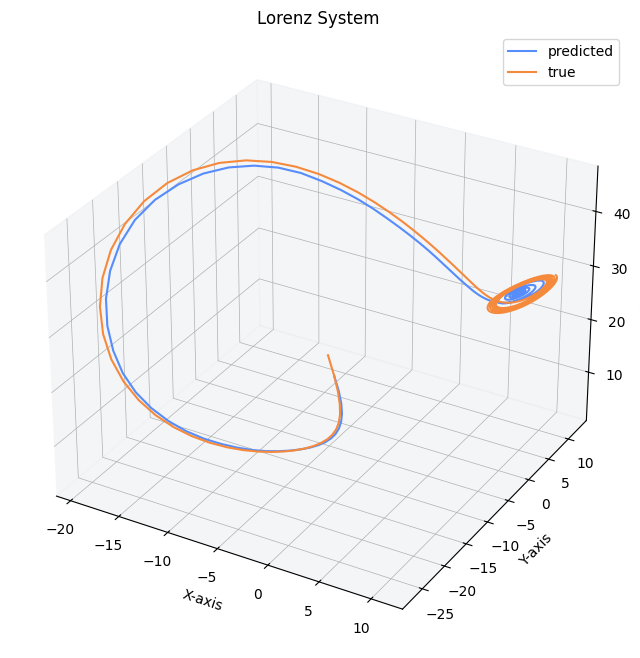

In [17]:
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection = '3d')
ax.plot(pred_i_physical.T[0], pred_i_physical.T[1], pred_i_physical.T[2], label="predicted")
ax.plot(true_i_physical.T[0], true_i_physical.T[1], true_i_physical.T[2], label="true")
ax.set_xlabel('X-axis')
ax.set_ylabel('Y-axis')
ax.set_zlabel('Z-axis')
ax.set_title('Lorenz System')
plt.legend()
plt.show()

### Noise

Now we repeat all of the steps for MLP, but our training data

In [40]:
small_noise = 1e-1
large_noise = 10

train_loader_sn, val_loader_sn, traj_train_sn, traj_test_sn, mins_sn, maxs_sn = setup_training_dataset(solutions3, small_noise)
train_loader_ln, val_loader_ln, traj_train_ln, traj_test_ln, mins_ln, maxs_ln = setup_training_dataset(solutions3, large_noise)

[[[-0.13388412  0.20301362 -0.17016794 ... -0.03504523 -0.12770326
   -0.01917971]
  [ 0.00320345  0.08820739  0.00498215 ...  0.06849468 -0.10150622
   -0.19833015]
  [ 0.24531032  0.04253758  0.06867225 ...  0.11262479  0.07063322
   -0.04907774]]

 [[ 0.11160107 -0.08010192 -0.14802427 ...  0.07063118 -0.03170772
   -0.02782698]
  [-0.19488193  0.08271434 -0.0758292  ... -0.04685241  0.13081895
   -0.07667584]
  [-0.03005904  0.08610374  0.09204048 ... -0.09089989 -0.11174125
   -0.00502781]]

 [[ 0.03282769  0.23371421  0.00655394 ... -0.06023458  0.04014497
   -0.03301181]
  [ 0.05083134  0.17503538 -0.17729291 ... -0.04843958  0.00283
    0.03496186]
  [ 0.03488805 -0.03166799 -0.28608051 ... -0.02721331  0.10935634
   -0.0381291 ]]

 ...

 [[-0.00989432  0.09695954  0.01215371 ... -0.1683171   0.01039541
    0.09592624]
  [ 0.04899289 -0.0113117  -0.02646534 ...  0.10930937  0.10002558
    0.02816383]
  [ 0.15456669  0.12704847 -0.00486423 ... -0.03721721  0.02858441
   -0.01375

In [31]:
model_sn = FeedForwardNN(dim=3, hidden=100).to(device)
model_ln = FeedForwardNN(dim=3, hidden=100).to(device)

optimizer_sn = torch.optim.Adam(model_sn.parameters(), lr=1e-3)
optimizer_ln = torch.optim.Adam(model_ln.parameters(), lr=1e-3)

In [32]:
hist_sn = train_model(model_sn, train_loader_sn, optimizer_sn, loss_fn, epochs=200, val_loader=val_loader_sn)

Epoch 1/200 - loss: 0.0214329 - val_loss: 0.000560257
Epoch 10/200 - loss: 6.39094e-05 - val_loss: 6.66083e-05
Epoch 20/200 - loss: 4.82418e-05 - val_loss: 4.58081e-05
Epoch 30/200 - loss: 4.42623e-05 - val_loss: 4.68649e-05
Epoch 40/200 - loss: 4.47294e-05 - val_loss: 4.30714e-05
Epoch 50/200 - loss: 4.5838e-05 - val_loss: 4.82966e-05
Epoch 60/200 - loss: 4.41437e-05 - val_loss: 5.73938e-05
Epoch 70/200 - loss: 4.53494e-05 - val_loss: 4.56859e-05
Epoch 80/200 - loss: 4.80217e-05 - val_loss: 4.13203e-05
Epoch 90/200 - loss: 4.84202e-05 - val_loss: 5.60883e-05
Epoch 100/200 - loss: 4.38306e-05 - val_loss: 5.18092e-05
Epoch 110/200 - loss: 4.23415e-05 - val_loss: 4.40082e-05
Epoch 120/200 - loss: 4.23325e-05 - val_loss: 5.62602e-05
Epoch 130/200 - loss: 4.16681e-05 - val_loss: 4.37524e-05
Epoch 140/200 - loss: 4.18383e-05 - val_loss: 4.13247e-05
Epoch 150/200 - loss: 4.58254e-05 - val_loss: 4.09288e-05
Epoch 160/200 - loss: 4.1354e-05 - val_loss: 4.29088e-05
Epoch 170/200 - loss: 4.58396

In [33]:
hist_ln = train_model(model_ln, train_loader_ln, optimizer_ln, loss_fn, epochs=200, val_loader=val_loader_ln)

Epoch 1/200 - loss: 0.0581515 - val_loss: 0.0486574
Epoch 10/200 - loss: 0.048546 - val_loss: 0.0479191
Epoch 20/200 - loss: 0.0484143 - val_loss: 0.0481817
Epoch 30/200 - loss: 0.0484132 - val_loss: 0.0480513
Epoch 40/200 - loss: 0.0483384 - val_loss: 0.0478999
Epoch 50/200 - loss: 0.048358 - val_loss: 0.0479388
Epoch 60/200 - loss: 0.0483157 - val_loss: 0.0478167
Epoch 70/200 - loss: 0.0482813 - val_loss: 0.0477539
Epoch 80/200 - loss: 0.0482804 - val_loss: 0.0479061
Epoch 90/200 - loss: 0.0483056 - val_loss: 0.0479941
Epoch 100/200 - loss: 0.0483071 - val_loss: 0.0480367
Epoch 110/200 - loss: 0.048245 - val_loss: 0.0478081
Epoch 120/200 - loss: 0.0482311 - val_loss: 0.0481467
Epoch 130/200 - loss: 0.0482937 - val_loss: 0.0477974
Epoch 140/200 - loss: 0.0482789 - val_loss: 0.0479908
Epoch 150/200 - loss: 0.0482045 - val_loss: 0.0479741
Epoch 160/200 - loss: 0.0482321 - val_loss: 0.0477876
Epoch 170/200 - loss: 0.0482497 - val_loss: 0.0479656
Epoch 180/200 - loss: 0.0482076 - val_loss

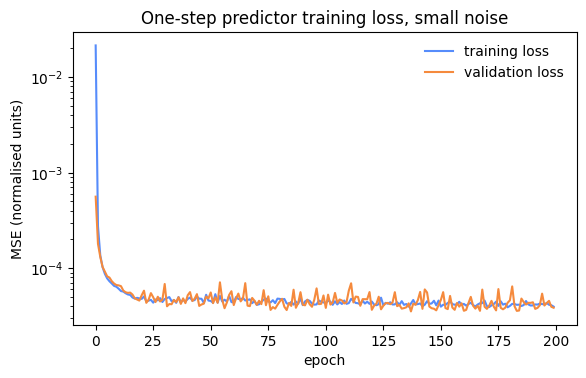

In [38]:
fig, ax = plt.subplots(figsize=(6.5, 3.8))
ax.semilogy(hist_sn.history["loss"], label="training loss")
ax.semilogy(hist_sn.history["val_loss"], label="validation loss")
ax.legend(frameon=False)
ax.set_xlabel("epoch")
ax.set_ylabel("MSE (normalised units)")
ax.set_title("One-step predictor training loss, small noise")
plt.show()

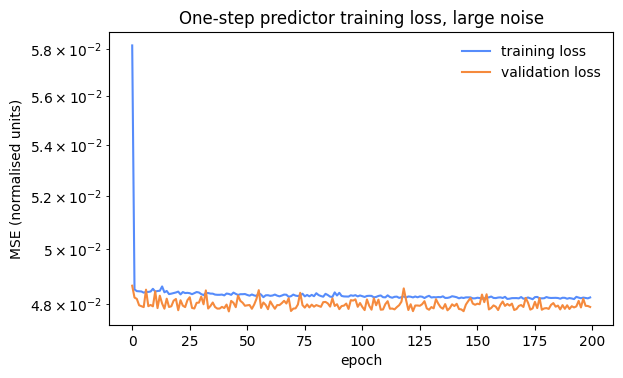

In [35]:
fig, ax = plt.subplots(figsize=(6.5, 3.8))
ax.semilogy(hist_ln.history["loss"], label="training loss")
ax.semilogy(hist_ln.history["val_loss"], label="validation loss")
ax.legend(frameon=False)
ax.set_xlabel("epoch")
ax.set_ylabel("MSE (normalised units)")
ax.set_title("One-step predictor training loss, large noise")
plt.show()

In [36]:
global_target_minvals = np.array([-1,-1,0])
global_target_maxvals = np.array([1,1,2])

true_i_normalized_sn = traj_test[3]
pred_i_normalized_sn = rollout(model_sn, true_i_normalized_sn[1], 400 - 2)

true_i_normalized_ln = traj_test[3]
pred_i_normalized_ln = rollout(model_ln, true_i_normalized_ln[1], 400 - 2)

true_i_physical_sn = denormalize(true_i_normalized_sn, mins_sn, maxs_sn, global_target_minvals, global_target_maxvals)
pred_i_physical_sn = denormalize(pred_i_normalized_sn, mins_sn, maxs_sn, global_target_minvals, global_target_maxvals)


true_i_physical_ln = denormalize(true_i_normalized_ln, mins_ln, maxs_ln, global_target_minvals, global_target_maxvals)
pred_i_physical_ln = denormalize(pred_i_normalized_ln, mins_ln, maxs_ln, global_target_minvals, global_target_maxvals)

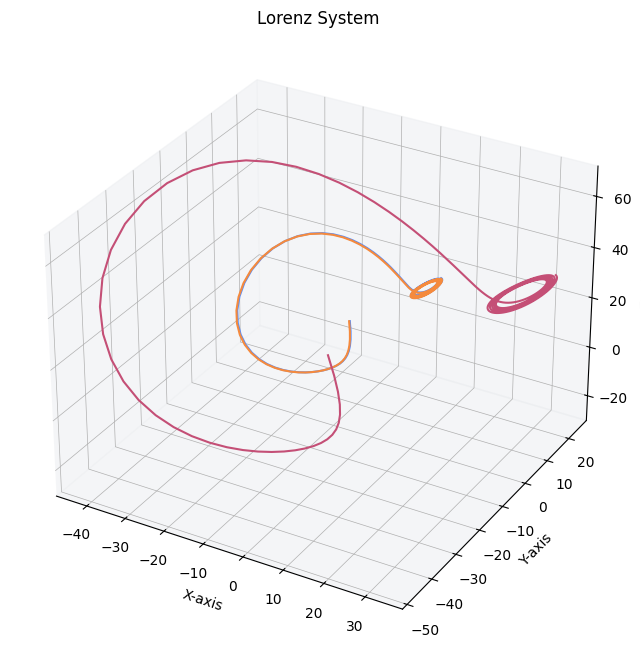

In [37]:
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection = '3d')
# ax.plot(pred_i_physical.T[0], pred_i_physical.T[1], pred_i_physical.T[2])
ax.plot(true_i_physical.T[0], true_i_physical.T[1], true_i_physical.T[2])

# ax.plot(pred_i_physical_sn.T[0], pred_i_physical_sn.T[1], pred_i_physical_sn.T[2])
ax.plot(true_i_physical_sn.T[0], true_i_physical_sn.T[1], true_i_physical_sn.T[2])

# ax.plot(pred_i_physical_ln.T[0], pred_i_physical_ln.T[1], pred_i_physical_ln.T[2])
ax.plot(true_i_physical_ln.T[0], true_i_physical_ln.T[1], true_i_physical_ln.T[2])

ax.set_xlabel('X-axis')
ax.set_ylabel('Y-axis')
ax.set_zlabel('Z-axis')
ax.set_title('Lorenz System')
plt.show()

## ODE

In [ ]:
class TrueLorenz(nn.Module):
    def __init__(self, rho=28., sig = 10., beta = 8./3.):
        super().__init__()
        self.rho = rho
        self.sig = sig
        self.beta = beta

    def forward(self, t, X):
        x,y,z = X.T
        f = torch.stack([self.sig*(y-x), x*(self.rho-z)-y, x*y-self.beta*z], dim = -1)
        return f


true_rhs = TrueLorenz(rho=28., sig = 10., beta = 8./3.).to(device)



In [ ]:
N_TRAJ = 100
N_TIME = 400
T = 4.0

t = torch.linspace(0.0, T, N_TIME, device=device)
dt = t[1] - t[0]

start_point = torch.tensor([-15.0, -15.0, 0.0], device=device)
end_point = torch.tensor([15.0, 15.0, 30.0], device=device)

x_initial = torch.linspace(start_point[0], end_point[0], N_TRAJ, device=device)
y_initial = torch.linspace(start_point[1], end_point[1], N_TRAJ, device=device)
z_initial = torch.linspace(start_point[2], end_point[2], N_TRAJ, device=device)
x0_train= torch.stack([x_initial, y_initial, z_initial], dim=1) # shape (N_TRAJ, 3)
with torch.no_grad():
    x_obs = odeint(true_rhs, x0_train, t, method="dopri5")  # [N_TIME, N_TRAJ, 3]

print(type(x_obs))
x_obs = x_obs.permute(1, 0, 2).contiguous()

<class 'torch.Tensor'>


In [ ]:
np.shape(x_obs[0])

torch.Size([400, 3])

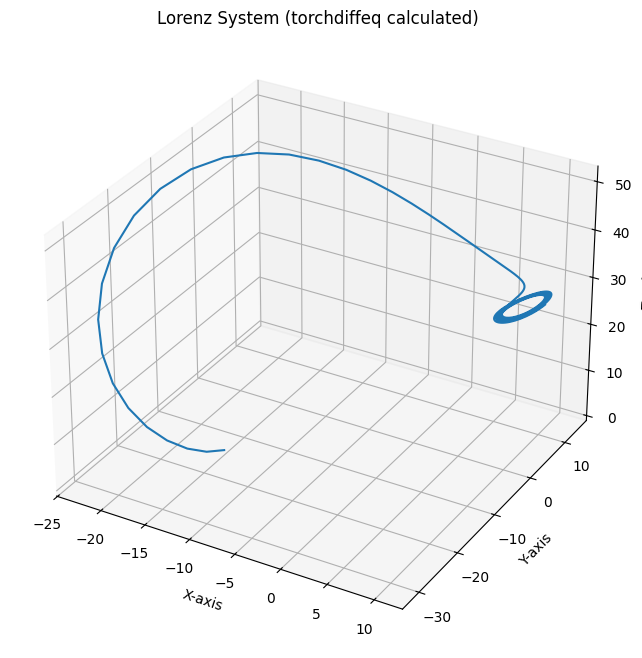

In [ ]:
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection = '3d')
ax.plot(x_obs[0,:,0], x_obs[0,:,1], x_obs[0,:,2])
# ax.plot(solutions3[0,0], solutions3[0,1], solutions3[0,2])
# ax.plot(pred_i_physical.T[0], pred_i_physical.T[1], pred_i_physical.T[2])
ax.set_xlabel('X-axis')
ax.set_ylabel('Y-axis')
ax.set_zlabel('Z-axis')
ax.set_title('Lorenz System (torchdiffeq calculated)')
plt.show()

In [ ]:
class Neural(nn.Module):
    def __init__(self, hidden_dim=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(3, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, 3),
        )

        # Normalization buffers make optimization less sensitive to units.
        self.register_buffer("x_mean", torch.zeros(3))
        self.register_buffer("x_std", torch.ones(3))
        self.register_buffer("dxdt_std", torch.ones(3))

    def set_normalization(self, x_mean, x_std, dxdt_std):
        self.x_mean.copy_(x_mean)
        self.x_std.copy_(x_std)
        self.dxdt_std.copy_(dxdt_std)

    def forward(self, t, x):
        x_norm = (x - self.x_mean) / self.x_std
        return self.dxdt_std * self.net(x_norm)

In [ ]:
def estimate_normalization(x_data):
    # x_data is [N_TRAJ, N_TIME, 3]
    # Calculate mean and std per coordinate (X, Y, Z)
    x_flat = x_data.reshape(-1, 3)
    x_mean = x_flat.mean(0)
    x_std = x_flat.std(0).clamp_min(1e-6)

    # Estimate dxdt scale for the output layer
    dxdt = (x_data[:, 1:] - x_data[:, :-1]) / dt
    dxdt_std = dxdt.reshape(-1, 3).std(0).clamp(min=0.1)
    return x_mean, x_std, dxdt_std

model = Neural(hidden_dim=64).to(device)
x_mean, x_std, dxdt_std = estimate_normalization(x_obs)
model.set_normalization(x_mean, x_std, dxdt_std)
print(f"Means: {x_mean.cpu().numpy()}")
print(f"Stds: {x_std.cpu().numpy()}")

Means: [ 4.279113   4.3855305 24.853025 ]
Stds: [7.0960445 7.9832463 7.3242984]


In [ ]:
WINDOW_SIZE = 50
BATCH_SIZE = 32

t_window = torch.arange(WINDOW_SIZE, device=device).float() * dt

def sample_window_batch(x_data, batch_size=BATCH_SIZE, window_size=WINDOW_SIZE):
    n_traj, n_time, _ = x_data.shape
    traj_idx = np.random.randint(0, n_traj, size=batch_size)
    starts = np.random.randint(0, n_time - window_size, size=batch_size)

    x0_batch = torch.stack([x_data[j, s] for j, s in zip(traj_idx, starts)])
    y_batch = torch.stack([x_data[j, s:s + window_size] for j, s in zip(traj_idx, starts)])
    return x0_batch, y_batch


x0_batch, y_batch = sample_window_batch(x_obs)
print("x0_batch:", tuple(x0_batch.shape))
print("y_batch:", tuple(y_batch.shape))

x0_batch: (32, 3)
y_batch: (32, 50, 3)


In [ ]:
optimizer = optim.Adam(model.parameters(), lr=1e-3)
loss_fn = nn.MSELoss()

N_STEPS = 2000
losses = []

model.train()
for step in range(1, N_STEPS + 1):
    x0_batch, y_batch = sample_window_batch(x_obs)

    # pred: [WINDOW_SIZE, BATCH_SIZE, 3]
    pred = odeint(model, x0_batch, t_window, method="rk4")

    # target: [BATCH_SIZE, WINDOW_SIZE, 3] -> permute to [WINDOW_SIZE, BATCH_SIZE, 3]
    target = y_batch.permute(1, 0, 2)

    loss = loss_fn(pred, target)

    optimizer.zero_grad()
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
    optimizer.step()

    if step == 1 or step % 10 == 0:
        losses.append((step, float(loss.item())))

    if step % 100 == 0:
        print(f"step {step:4d} | loss {loss.item():.4e}")

step  100 | loss 6.3454e-01
step  200 | loss 3.5675e-01
step  300 | loss 1.0941e-01
step  400 | loss 6.3200e-01
step  500 | loss 2.2074e-01
step  600 | loss 9.4928e-01
step  700 | loss 1.2846e-01
step  800 | loss 1.9994e-01
step  900 | loss 1.4481e-01


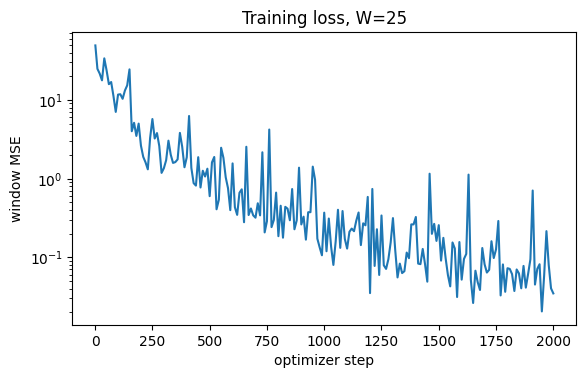

<Figure size 640x480 with 0 Axes>

In [ ]:
losses = np.array(losses)

fig, ax = plt.subplots(figsize=(6.5, 3.8))
ax.plot(losses[:, 0], losses[:, 1])
ax.set_yscale("log")
ax.set_xlabel("optimizer step")
ax.set_ylabel("window MSE")
ax.set_title(f"Training loss, W={WINDOW_SIZE}")
plt.show()
plt.savefig('loss50.png')

In [ ]:
losses = np.array(losses)

fig, ax = plt.subplots(figsize=(6.5, 3.8))
ax.plot(losses[:, 0], losses[:, 1])
ax.set_yscale("log")
ax.set_xlabel("optimizer step")
ax.set_ylabel("window MSE")
ax.set_title(f"Training loss, W={WINDOW_SIZE}")
plt.show()
plt.savefig('loss25.png')

In [ ]:
t_eval = torch.linspace(0.0, 4.0, 400, device=device)
x0_eval = torch.tensor([[0.03, 5.0, 5.0]], device=device)

# Get ground truth
with torch.no_grad():
    true_trajectory = odeint(true_rhs, x0_eval, t_eval, method="dopri5") # [400, 1, 3]

# Get prediction
model.eval()
with torch.no_grad():
     # Pass the first (and only) row of x0_eval
     pred_trajectory = odeint(model, x0_eval[0:1], t_eval, method="dopri5") # [400, 1, 3]

# Prepare for plotting: remove batch dimension and move to CPU
pred_plot = pred_trajectory[:, 0, :].cpu().numpy()
true_plot = true_trajectory[:, 0, :].cpu().numpy()


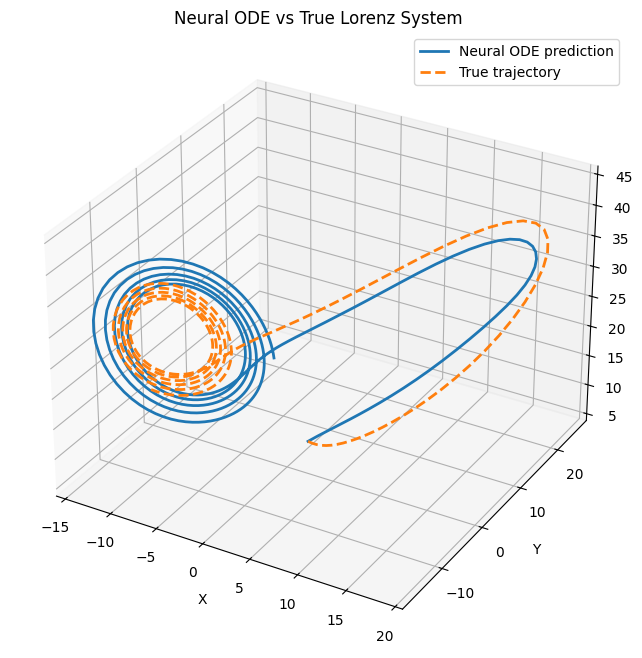

In [ ]:
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

ax.plot(pred_plot[:, 0], pred_plot[:, 1], pred_plot[:, 2],
        label='Neural ODE prediction', lw=2, color='C0')
ax.plot(true_plot[:, 0], true_plot[:, 1], true_plot[:, 2],
        label='True trajectory', lw=2, ls='--', color='C1')

ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.set_title('Neural ODE vs True Lorenz System')
ax.legend()
plt.show()

In [ ]:
### Noise ODE

### Noise ODE

In [ ]:
x_obs_np = x_obs.cpu().numpy()
noise = 1e-4*np.random.randn(*np.array(x_obs_np).shape).astype(np.float32)
x_obs_noisy = x_obs.add(torch.tensor(noise).to(device))

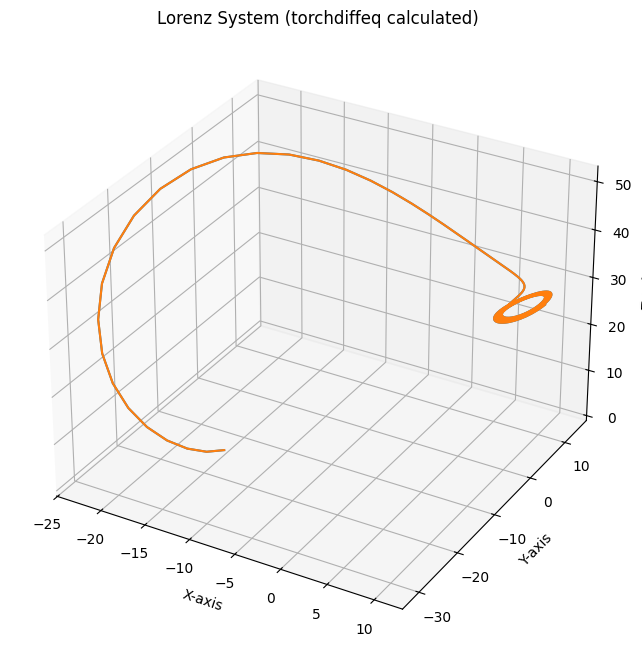

In [ ]:
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection = '3d')
ax.plot(x_obs_noisy[0,:,0], x_obs_noisy[0,:,1], x_obs_noisy[0,:,2])
ax.plot(x_obs[0,:,0], x_obs[0,:,1], x_obs[0,:,2])
# ax.plot(pred_i_physical.T[0], pred_i_physical.T[1], pred_i_physical.T[2])
ax.set_xlabel('X-axis')
ax.set_ylabel('Y-axis')
ax.set_zlabel('Z-axis')
ax.set_title('Lorenz System (torchdiffeq calculated)')
plt.show()

In [ ]:
class Neural(nn.Module):
    def __init__(self, hidden_dim=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(3, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, 3),
        )

        # Normalization buffers make optimization less sensitive to units.
        self.register_buffer("x_mean", torch.zeros(3))
        self.register_buffer("x_std", torch.ones(3))
        self.register_buffer("dxdt_std", torch.ones(3))

    def set_normalization(self, x_mean, x_std, dxdt_std):
        self.x_mean.copy_(x_mean)
        self.x_std.copy_(x_std)
        self.dxdt_std.copy_(dxdt_std)

    def forward(self, t, x):
        x_norm = (x - self.x_mean) / self.x_std
        return self.dxdt_std * self.net(x_norm)

In [ ]:
def estimate_normalization(x_data):
    # x_data is [N_TRAJ, N_TIME, 3]
    # Calculate mean and std per coordinate (X, Y, Z)
    x_flat = x_data.reshape(-1, 3)
    x_mean = x_flat.mean(0)
    x_std = x_flat.std(0).clamp_min(1e-6)

    # Estimate dxdt scale for the output layer
    dxdt = (x_data[:, 1:] - x_data[:, :-1]) / dt
    dxdt_std = dxdt.reshape(-1, 3).std(0).clamp(min=0.1)
    return x_mean, x_std, dxdt_std

model = Neural(hidden_dim=64).to(device)
x_mean, x_std, dxdt_std = estimate_normalization(x_obs_noisy)
model.set_normalization(x_mean, x_std, dxdt_std)
print(f"Means: {x_mean.cpu().numpy()}")
print(f"Stds: {x_std.cpu().numpy()}")

Means: [ 4.2791133  4.3855314 24.853027 ]
Stds: [7.096044  7.983246  7.3242984]


In [ ]:
WINDOW_SIZE = 50
BATCH_SIZE = 32

t_window = torch.arange(WINDOW_SIZE, device=device).float() * dt

def sample_window_batch(x_data, batch_size=BATCH_SIZE, window_size=WINDOW_SIZE):
    n_traj, n_time, _ = x_data.shape
    traj_idx = np.random.randint(0, n_traj, size=batch_size)
    starts = np.random.randint(0, n_time - window_size, size=batch_size)

    x0_batch = torch.stack([x_data[j, s] for j, s in zip(traj_idx, starts)])
    y_batch = torch.stack([x_data[j, s:s + window_size] for j, s in zip(traj_idx, starts)])
    return x0_batch, y_batch


x0_batch, y_batch = sample_window_batch(x_obs_noisy)
print("x0_batch:", tuple(x0_batch.shape))
print("y_batch:", tuple(y_batch.shape))

x0_batch: (32, 3)
y_batch: (32, 50, 3)


In [ ]:
optimizer = optim.Adam(model.parameters(), lr=1e-3)
loss_fn = nn.MSELoss()

N_STEPS = 2000
losses = []

model.train()
for step in range(1, N_STEPS + 1):
    x0_batch, y_batch = sample_window_batch(x_obs_noisy)

    # pred: [WINDOW_SIZE, BATCH_SIZE, 3]
    pred = odeint(model, x0_batch, t_window, method="rk4")

    # target: [BATCH_SIZE, WINDOW_SIZE, 3] -> permute to [WINDOW_SIZE, BATCH_SIZE, 3]
    target = y_batch.permute(1, 0, 2)

    loss = loss_fn(pred, target)

    optimizer.zero_grad()
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
    optimizer.step()

    if step == 1 or step % 10 == 0:
        losses.append((step, float(loss.item())))

    if step % 100 == 0:
        print(f"step {step:4d} | loss {loss.item():.4e}")

step  100 | loss 2.9539e+01
step  200 | loss 1.6972e+01
step  300 | loss 1.0920e+01
step  400 | loss 5.8341e+00
step  500 | loss 5.2418e+00
step  600 | loss 2.6402e+00
step  700 | loss 2.6808e+00
step  800 | loss 4.0174e+00
step  900 | loss 1.7467e+00
step 1000 | loss 9.7957e-01
step 1100 | loss 2.1786e+00
step 1200 | loss 2.7413e+00
step 1300 | loss 9.6350e-01
step 1400 | loss 1.3369e+00
step 1500 | loss 4.6417e-01
step 1600 | loss 6.1100e-01
step 1700 | loss 5.4202e-01
step 1800 | loss 2.8198e+00
step 1900 | loss 3.7855e-01
step 2000 | loss 5.1701e-01


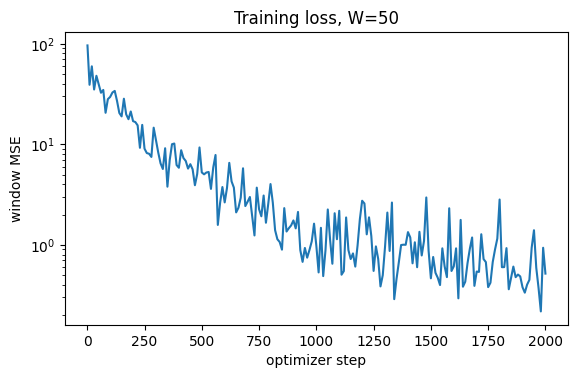

<Figure size 640x480 with 0 Axes>

In [ ]:
losses = np.array(losses)

fig, ax = plt.subplots(figsize=(6.5, 3.8))
ax.plot(losses[:, 0], losses[:, 1])
ax.set_yscale("log")
ax.set_xlabel("optimizer step")
ax.set_ylabel("window MSE")
ax.set_title(f"Training loss, W={WINDOW_SIZE}")
plt.show()
plt.savefig('loss50.png')

In [ ]:
t_eval = torch.linspace(0.0, 4.0, 400, device=device)
x0_eval = torch.tensor([[0.03, 5.0, 5.0]], device=device)

# Get ground truth
with torch.no_grad():
    true_trajectory = odeint(true_rhs, x0_eval, t_eval, method="dopri5") # [400, 1, 3]

# Get prediction
model.eval()
with torch.no_grad():
     # Pass the first (and only) row of x0_eval
     pred_trajectory = odeint(model, x0_eval[0:1], t_eval, method="dopri5") # [400, 1, 3]

# Prepare for plotting: remove batch dimension and move to CPU
pred_plot = pred_trajectory[:, 0, :].cpu().numpy()
true_plot = true_trajectory[:, 0, :].cpu().numpy()

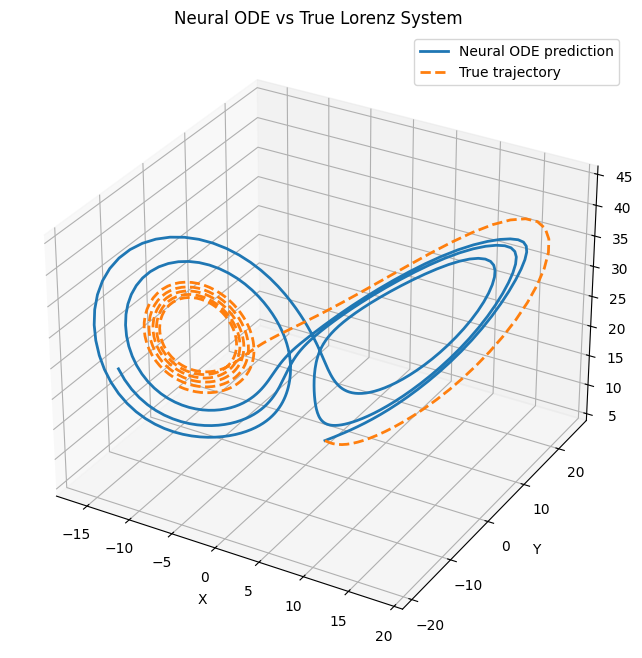

In [ ]:
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

ax.plot(pred_plot[:, 0], pred_plot[:, 1], pred_plot[:, 2],
        label='Neural ODE prediction', lw=2, color='C0')
ax.plot(true_plot[:, 0], true_plot[:, 1], true_plot[:, 2],
        label='True trajectory', lw=2, ls='--', color='C1')

ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.set_title('Neural ODE vs True Lorenz System')
ax.legend()
plt.show()